In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurações padrão para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = '../data/final/dataset_gramado_completo.parquet'
IMAGE_DIR = '../data/images'

os.makedirs(IMAGE_DIR, exist_ok=True)

df = pd.read_parquet(DATA_PATH)

print(f"Dataset carregado com {df.shape[0]} filmes e {df.shape[1]} colunas.")

Dataset carregado com 160 filmes e 15 colunas.


In [ ]:
# Extração do score geral de sentimento do Gemini para cada filme
def extrair_score(analise):
    if isinstance(analise, dict):
        metadados = analise.get('metadados_grafico')
        if isinstance(metadados, dict):
            return metadados.get('sentimento_geral_score')
    return None

df['gemini_score'] = df['analise_gemini'].apply(extrair_score)

# Flattening dos dados para que o seaborn consiga ler e plotar
registros_tags = []
for index, row in df.iterrows():
    analise = row['analise_gemini']
    if isinstance(analise, dict) and isinstance(analise.get('metadados_grafico'), dict):
        metricas = analise['metadados_grafico'].get('metricas', [])
        for metrica in metricas:
            registros_tags.append({
                'id_movie': row['id_movie'],
                'aspecto': metrica.get('aspecto'),
                'nivel': metrica.get('nivel'),
                'tag_tendencia': metrica.get('tag_tendencia')
            })

df_todas_tags = pd.DataFrame(registros_tags)

# Conta a frequência e rankeia as top 5 tags por filme
if not df_todas_tags.empty:
    df_contagem = df_todas_tags.groupby(
        ['id_movie', 'aspecto', 'nivel', 'tag_tendencia']
    ).size().reset_index(name='frequencia')

    df_contagem = df_contagem.sort_values(by=['id_movie', 'frequencia'], ascending=[True, False])
    df_tags = df_contagem.groupby('id_movie').head(5).copy()
    df_tags = df_tags.drop(columns=['frequencia'])
else:
    df_tags = pd.DataFrame(columns=['id_movie', 'aspecto', 'nivel', 'tag_tendencia'])

# Traz de volta as colunas que vão ser usadas nos gráficos
colunas_para_trazer = ['id_movie', 'title', 'genre', 'tema_principal', 'rating', 'gemini_score']
colunas_disponiveis = [col for col in colunas_para_trazer if col in df.columns]

df_tags = df_tags.merge(df[colunas_disponiveis], on='id_movie', how='left')


Total de filmes com análises estruturadas: 125
Total de tags no dataset (máx. 5 por filme): 620
Metadados (Gênero, Tema, etc) anexados com sucesso e prontos para os gráficos!


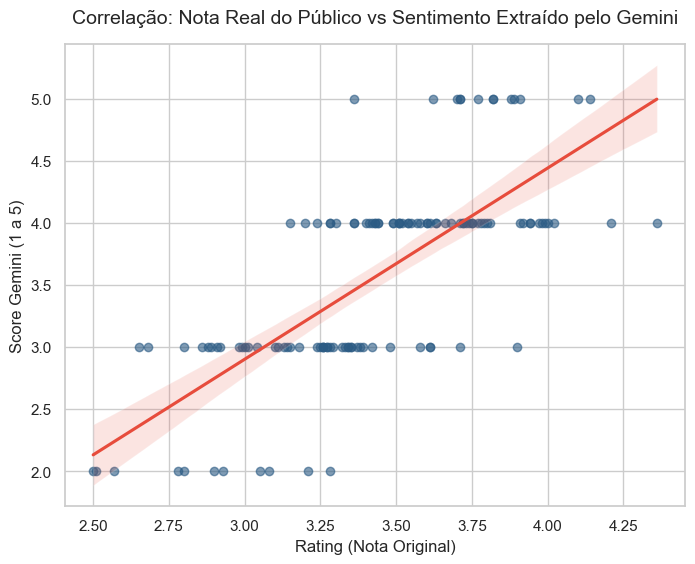

In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 1: Correlação entre a Nota do Público e a Análise do Gemini

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df, 
    x='rating', 
    y='gemini_score', 
    scatter_kws={'alpha':0.6, 'color': '#2b5b84'}, 
    line_kws={'color':'#e74c3c'}
)
plt.title('Correlação: Nota Real do Público vs Sentimento Extraído pelo Gemini', fontsize=14, pad=15)
plt.xlabel('Rating (Nota Original)')
plt.ylabel('Score Gemini (1 a 5)')

caminho_corr = os.path.join(IMAGE_DIR, 'correlacao_scores.png')
plt.savefig(caminho_corr, bbox_inches='tight', dpi=300) # tight para reduzir margens, dpi para alta resolução
plt.show()

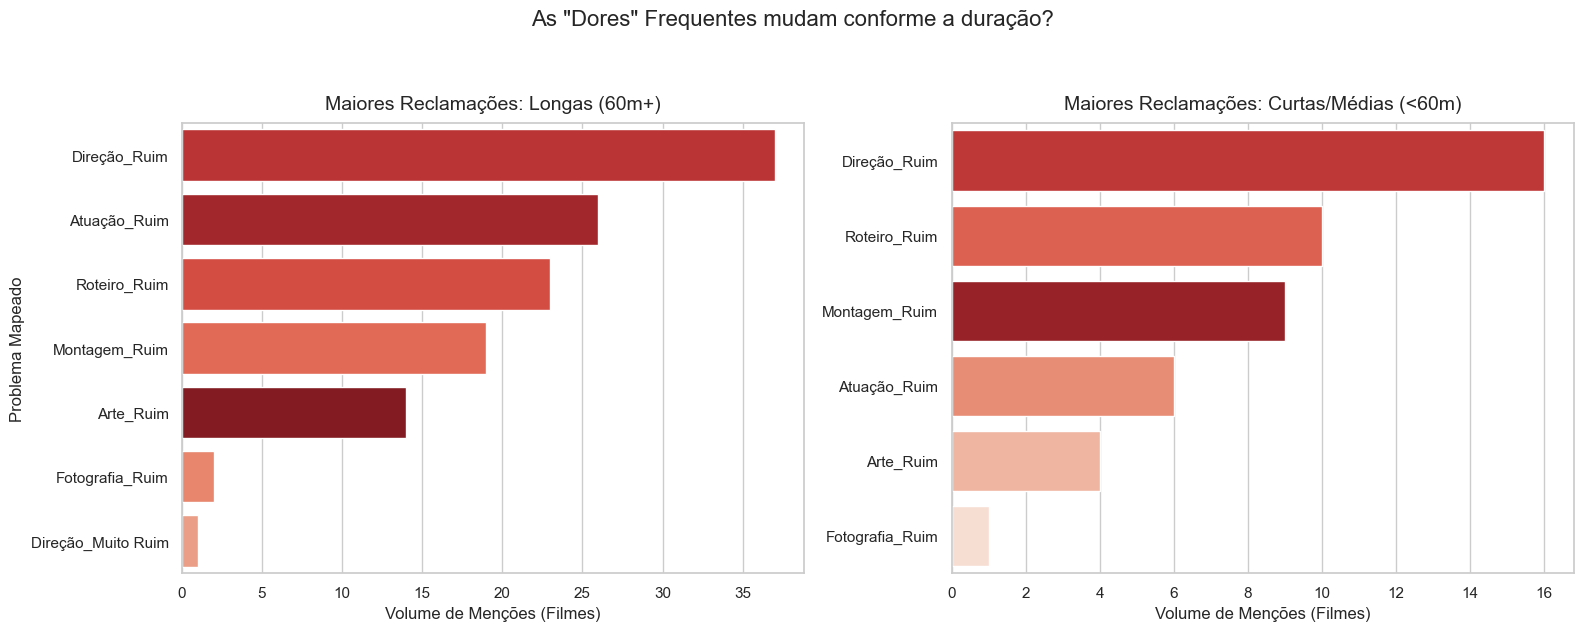

In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 2: A "Dor" do Cinema Nacional (Separado por Formato)

# incluindo a duração para separar os filmes em Curtas/Médias e Longas
df_tags_format = df_tags.merge(df[['id_movie', 'duration']], on='id_movie', how='left')
df_tags_format['formato'] = df_tags_format['duration'].apply(lambda x: 'Curtas/Médias (<60m)' if x < 60 else 'Longas (60m+)')

negativas = df_tags_format[df_tags_format['nivel'].isin(['Ruim', 'Muito Ruim'])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

for i, formato in enumerate(['Longas (60m+)', 'Curtas/Médias (<60m)']):
    dados_formato = negativas[negativas['formato'] == formato]
    
    if not dados_formato.empty:
        sns.countplot(
            data=dados_formato, 
            y='tag_tendencia',
            hue='tag_tendencia',
            order=dados_formato['tag_tendencia'].value_counts().index[:7], # Top 7 para ficar limpo
            palette='Reds_r', 
            ax=axes[i],
            legend=False
        )
    axes[i].set_title(f'Maiores Reclamações: {formato}', fontsize=14, pad=10)
    axes[i].set_xlabel('Volume de Menções (Filmes)')
    axes[i].set_ylabel('Problema Mapeado' if i == 0 else '')

plt.suptitle('As "Dores" Frequentes mudam conforme a duração?', fontsize=16, y=1.05)
plt.tight_layout()

caminho_dores = os.path.join(IMAGE_DIR, 'top_dores_separado.png')
plt.savefig(caminho_dores, bbox_inches='tight', dpi=300)
plt.show()

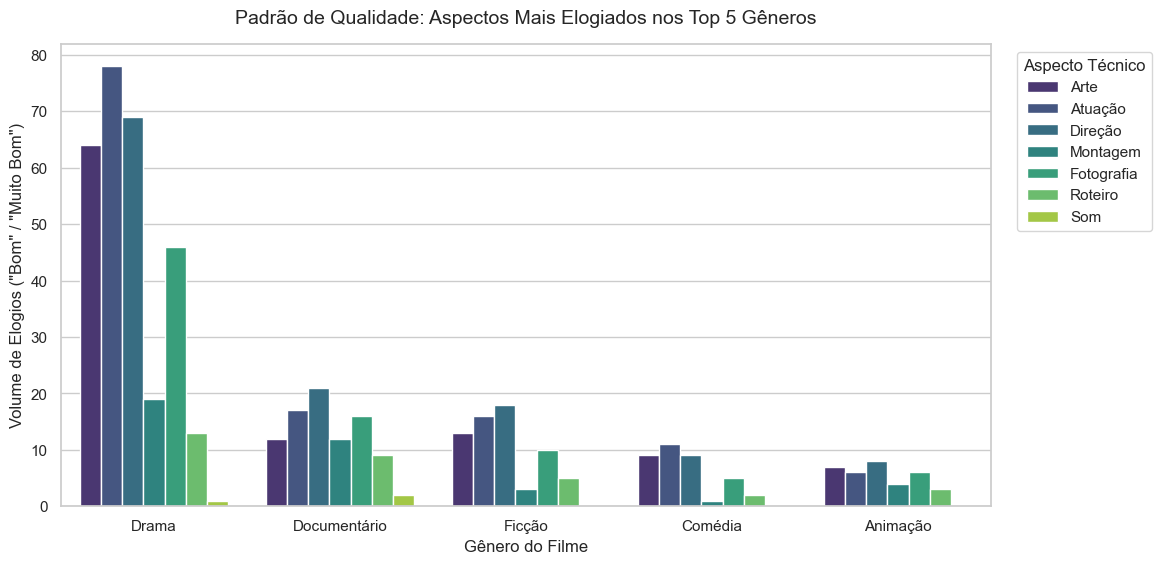

Salvo: ../data/images\forcas_por_genero.png


In [16]:
# -----------------------------------------------------------------------
# INSIGHT 3: Forças por Gênero (Onde cada gênero acerta?)
# Alguns filmes têm vários gêneros, precisando "explodir" a lista de gêneros

df_tags_exploded = df_tags.explode('genre')

top_5_generos = df_tags_exploded['genre'].value_counts().index[:5]
df_top_generos = df_tags_exploded[df_tags_exploded['genre'].isin(top_5_generos)]

# Filtramos apenas os elogios (Bom / Muito Bom)
positivas_genero = df_top_generos[df_top_generos['nivel'].isin(['Bom', 'Muito Bom'])]

plt.figure(figsize=(12, 6))
sns.countplot(
    data=positivas_genero, 
    x='genre', 
    hue='aspecto', 
    palette='viridis',
    order=top_5_generos
)
plt.title('Padrão de Qualidade: Aspectos Mais Elogiados nos Top 5 Gêneros', fontsize=14, pad=15)
plt.xlabel('Gênero do Filme')
plt.ylabel('Volume de Elogios ("Bom" / "Muito Bom")')
plt.legend(title='Aspecto Técnico', bbox_to_anchor=(1.02, 1), loc='upper left')

caminho_forcas = os.path.join(IMAGE_DIR, 'forcas_por_genero.png')
plt.savefig(caminho_forcas, bbox_inches='tight', dpi=300)
plt.show()
plt.close()
print(f"Salvo: {caminho_forcas}")

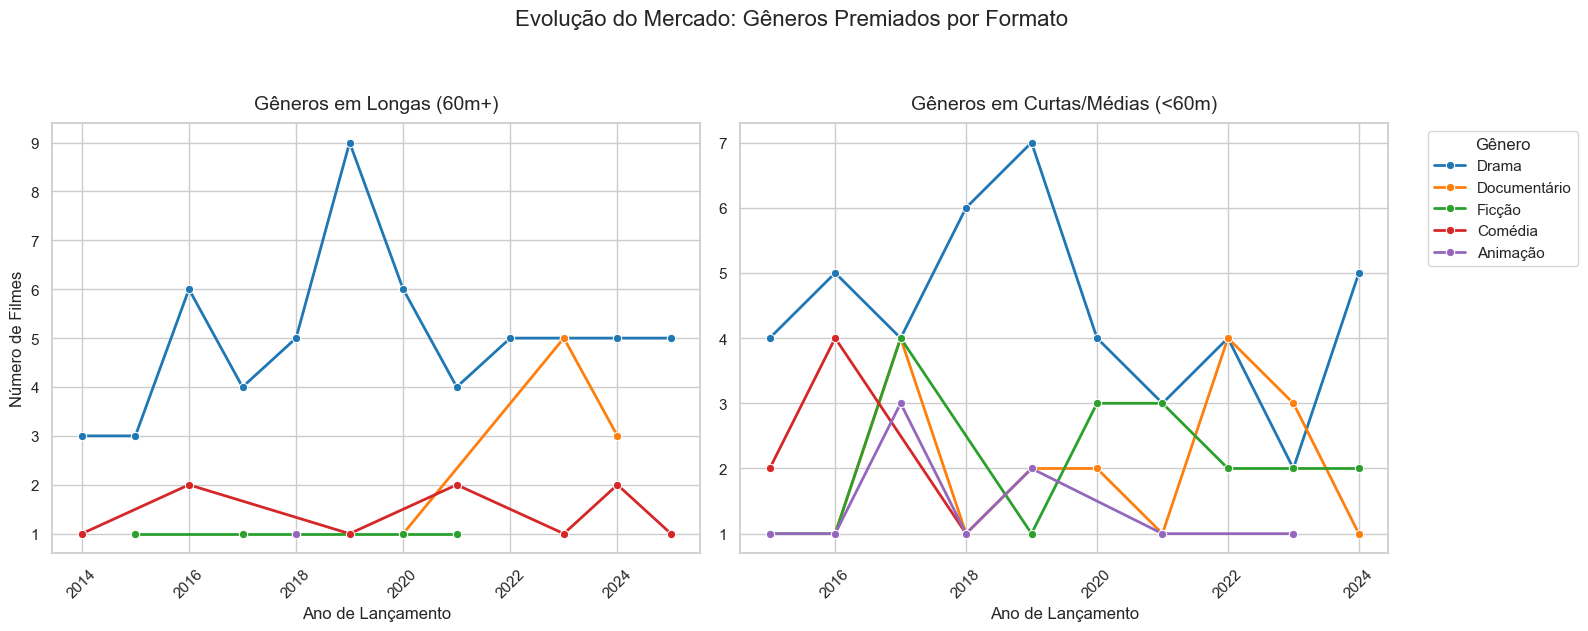

In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 4: Tendência de Gêneros ao Longo dos Anos (Longas vs Curtas)

df_exploded = df.explode('genre').copy()
df_exploded['formato'] = df_exploded['duration'].apply(lambda x: 'Curtas/Médias (<60m)' if x < 60 else 'Longas (60m+)')

# Pegamos os 5 gêneros mais comuns para não poluir o gráfico
top_generos = df_exploded['genre'].value_counts().index[:5]
df_trend = df_exploded[df_exploded['genre'].isin(top_generos)]

tendencia = df_trend.groupby(['release_year', 'genre', 'formato']).size().reset_index(name='qtd_filmes')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

ordem_generos = list(top_generos)

for i, formato in enumerate(['Longas (60m+)', 'Curtas/Médias (<60m)']):
    dados_formato = tendencia[tendencia['formato'] == formato]
    
    if not dados_formato.empty:
        sns.lineplot(
            data=dados_formato, 
            x='release_year', 
            y='qtd_filmes', 
            hue='genre', 
            hue_order=ordem_generos, # Trava a mesma cor para cada gênero nos dois gráficos
            marker='o',
            linewidth=2,
            palette='tab10',
            ax=axes[i],
            legend=(i == 1) # Mostra a legenda apenas no gráfico da direita
        )
    
    axes[i].set_title(f'Gêneros em {formato}', fontsize=14, pad=10)
    axes[i].set_xlabel('Ano de Lançamento')
    axes[i].set_ylabel('Número de Filmes' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=45)


if len(axes[1].get_legend_handles_labels()[0]) > 0: # Puxa a legenda para fora do quadro
    axes[1].legend(title='Gênero', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Evolução do Mercado: Gêneros Premiados por Duração', fontsize=16, y=1.05)
plt.tight_layout()

caminho_trend_gen = os.path.join(IMAGE_DIR, 'tendencia_generos_separado.png')
plt.savefig(caminho_trend_gen, bbox_inches='tight', dpi=300)
plt.show()

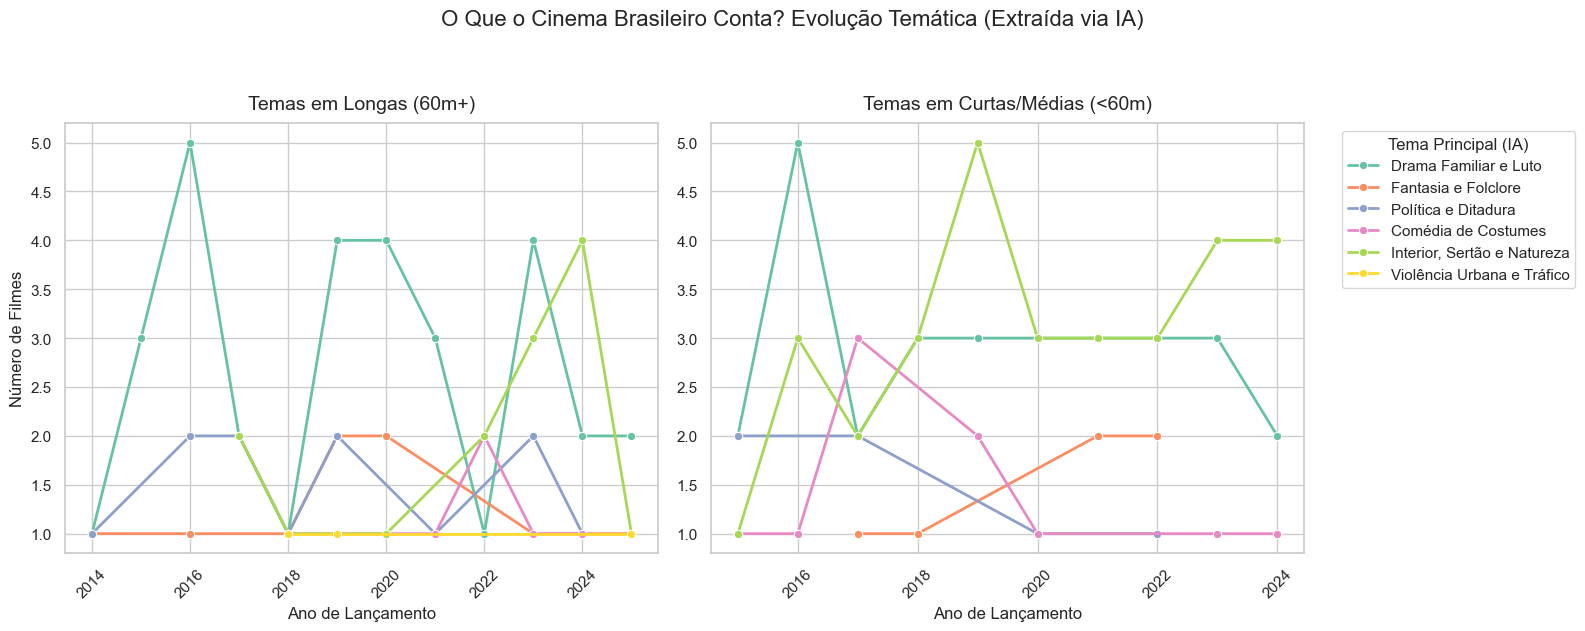

In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 5: Evolução dos Temas (NLP - BERT) ao Longo dos Anos

df_temas = df.copy()
df_temas['formato'] = df_temas['duration'].apply(lambda x: 'Curtas/Médias (<60m)' if x < 60 else 'Longas (60m+)')

df_temas = df_temas.dropna(subset=['tema_principal'])

ordem_temas = list(df_temas['tema_principal'].unique())

tendencia_temas = df_temas.groupby(['release_year', 'tema_principal', 'formato']).size().reset_index(name='qtd_filmes')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for i, formato in enumerate(['Longas (60m+)', 'Curtas/Médias (<60m)']):
    dados_formato = tendencia_temas[tendencia_temas['formato'] == formato]
    
    if not dados_formato.empty:
        sns.lineplot(
            data=dados_formato, 
            x='release_year', 
            y='qtd_filmes', 
            hue='tema_principal', 
            hue_order=ordem_temas,
            marker='o',
            linewidth=2,
            palette='Set2', 
            ax=axes[i],
            legend=(i == 1)
        )
    
    axes[i].set_title(f'Temas em {formato}', fontsize=14, pad=10)
    axes[i].set_xlabel('Ano de Lançamento')
    axes[i].set_ylabel('Número de Filmes' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=45)

if len(axes[1].get_legend_handles_labels()[0]) > 0:
    axes[1].legend(title='Tema Principal (IA)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('O Que o Cinema Brasileiro Conta? Evolução Temática (via BERT)', fontsize=16, y=1.05)
plt.tight_layout()

caminho_trend_temas = os.path.join(IMAGE_DIR, 'tendencia_temas_separado.png')
plt.savefig(caminho_trend_temas, bbox_inches='tight', dpi=300)
plt.show()

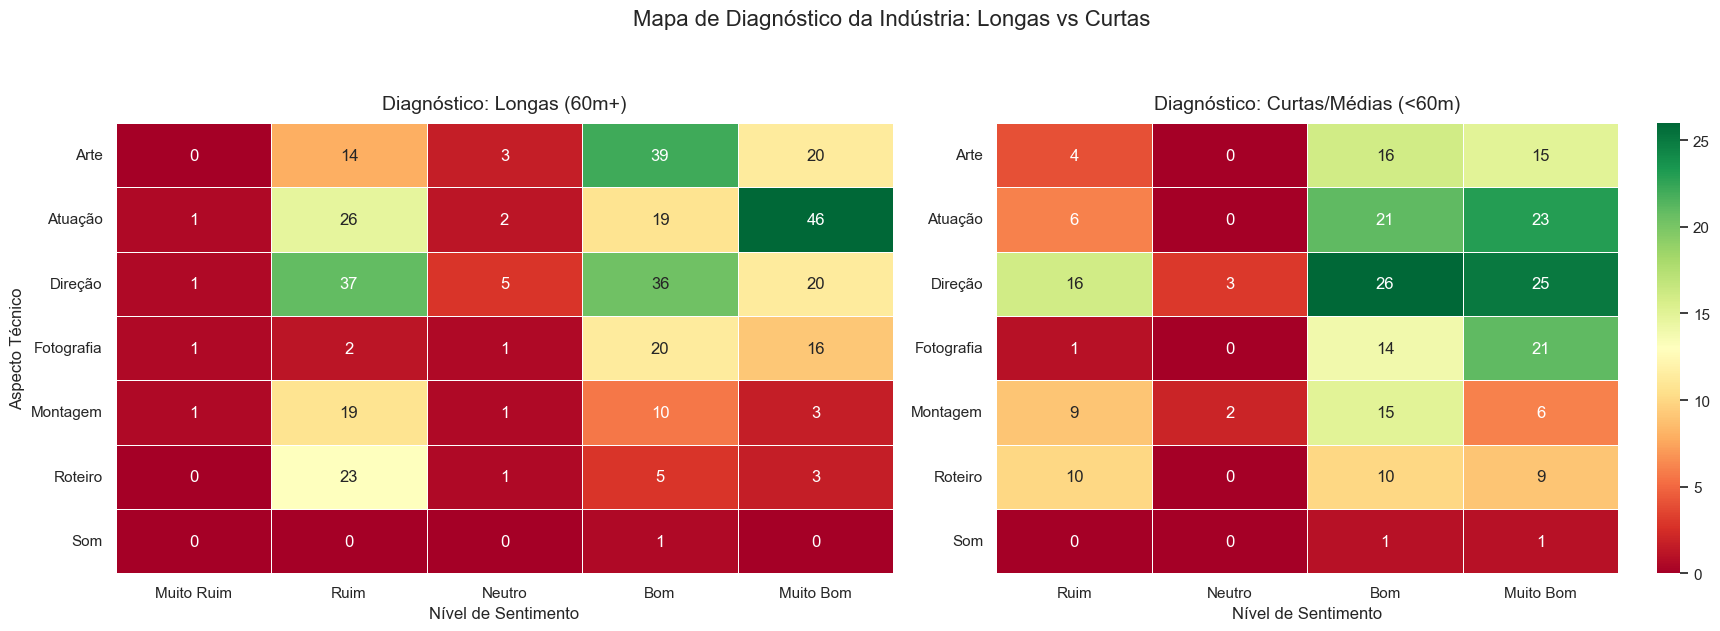

In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 6: Mapa de Calor Diagnóstico (Longas vs Curtas)

df_tags_format = df_tags.merge(df[['id_movie', 'duration']], on='id_movie', how='left')
df_tags_format['formato'] = df_tags_format['duration'].apply(lambda x: 'Curtas/Médias (<60m)' if x < 60 else 'Longas (60m+)')

ordem_niveis = ['Muito Ruim', 'Ruim', 'Neutro', 'Bom', 'Muito Bom']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, formato in enumerate(['Longas (60m+)', 'Curtas/Médias (<60m)']):
    df_fmt = df_tags_format[df_tags_format['formato'] == formato]
    
    if not df_fmt.empty:
        heatmap_data = pd.crosstab(df_fmt['aspecto'], df_fmt['nivel'])
        
        colunas_presentes = [col for col in ordem_niveis if col in heatmap_data.columns]
        heatmap_data = heatmap_data.reindex(columns=colunas_presentes, fill_value=0)
        
        sns.heatmap(
            heatmap_data, 
            annot=True,      
            fmt='d',         
            cmap='RdYlGn',   
            linewidths=.5,
            ax=axes[i],
            cbar=(i == 1) # Mostra a barra de cores só no gráfico da direita
        )
    axes[i].set_title(f'Diagnóstico: {formato}', fontsize=14, pad=10)
    axes[i].set_xlabel('Nível de Sentimento')
    axes[i].set_ylabel('Aspecto Técnico' if i == 0 else '')

plt.suptitle('Mapa de Diagnóstico: Longas vs Curtas', fontsize=16, y=1.05)
plt.tight_layout()

caminho_heatmap = os.path.join(IMAGE_DIR, 'heatmap_diagnostico_separado.png')
plt.savefig(caminho_heatmap, bbox_inches='tight', dpi=300)
plt.show()

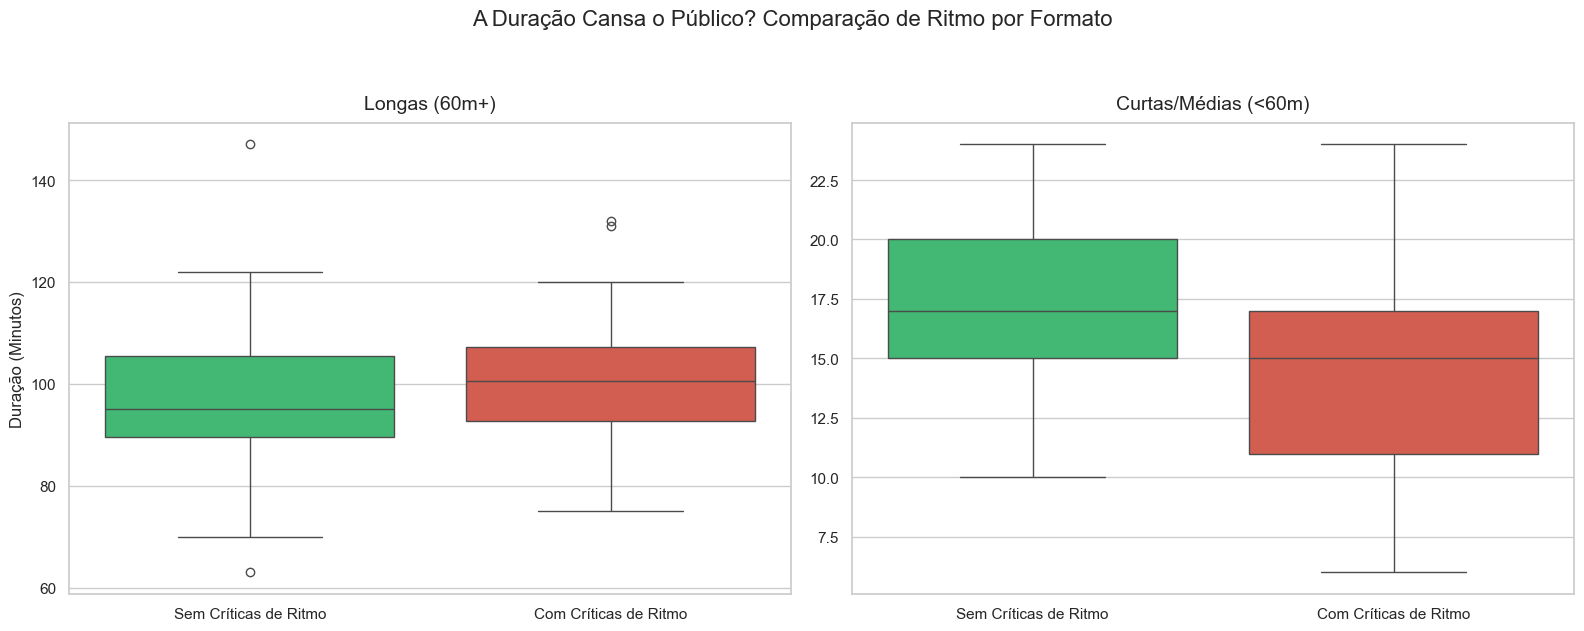

In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 7: Impacto da Duração nas Reclamações de Ritmo

df_boxplot = df.copy()
df_boxplot['formato'] = df_boxplot['duration'].apply(lambda x: 'Curtas/Médias (<60m)' if x < 60 else 'Longas (60m+)')

tags_ritmo = ['Montagem_Ruim', 'Montagem_Muito Ruim', 'Roteiro_Ruim', 'Roteiro_Muito Ruim']
filmes_lentos = df_tags[df_tags['tag_tendencia'].isin(tags_ritmo)]['id_movie'].unique()

# Elimina os nulos para não assumir falsamente que o filme tem ritmo bom só porque ninguém avaliou
df_boxplot = df_boxplot[df_boxplot['analise_gemini'].notnull()].copy()

df_boxplot['problema_ritmo'] = df_boxplot['id_movie'].apply(
    lambda x: 'Com Críticas de Ritmo' if x in filmes_lentos else 'Sem Críticas de Ritmo'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False) # sharey=False para permitir escalas diferentes

for i, formato in enumerate(['Longas (60m+)', 'Curtas/Médias (<60m)']):
    dados_formato = df_boxplot[df_boxplot['formato'] == formato]
    
    if not dados_formato.empty:
        sns.boxplot(
            data=dados_formato,
            x='problema_ritmo', 
            y='duration', 
            hue='problema_ritmo',
            palette={'Com Críticas de Ritmo': '#e74c3c', 'Sem Críticas de Ritmo': '#2ecc71'},
            ax=axes[i],
            legend=False
        )
    axes[i].set_title(f'{formato}', fontsize=14, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Duração (Minutos)' if i == 0 else '')

plt.suptitle('A Duração Cansa o Público? Comparação de Ritmo por Formato', fontsize=16, y=1.05)
plt.tight_layout()

caminho_boxplot = os.path.join(IMAGE_DIR, 'boxplot_ritmo_separado.png')
plt.savefig(caminho_boxplot, bbox_inches='tight', dpi=300)
plt.show()

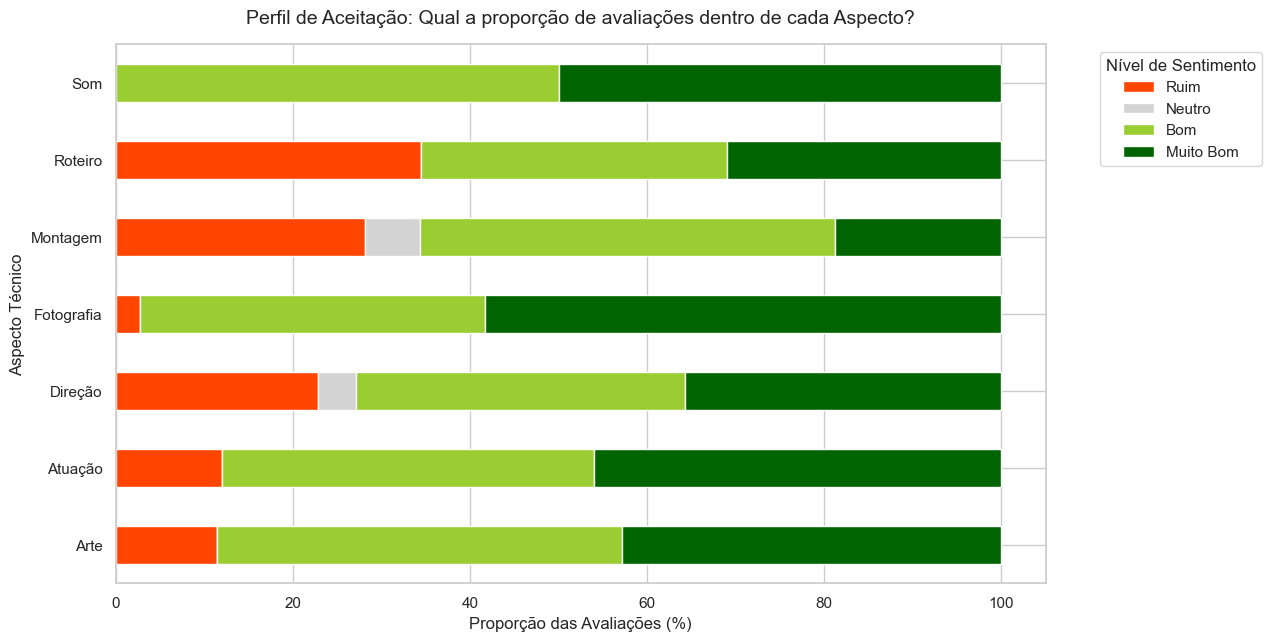

Salvo: ../data/images\barras_proporcao_sentimento.png
Gráficos gerados com sucesso!


In [ ]:
# -----------------------------------------------------------------------
# INSIGHT 8: Proporção de Sentimentos (Polarização)
# Transforma os dados absolutos do heatmap em porcentagens (soma da linha = 100%) para mostrar a polarização de cada aspecto

heatmap_perc = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

cores_niveis = {
    'Muito Ruim': '#8b0000', # Vermelho escuro
    'Ruim': '#ff4500',       # Laranja/Vermelho
    'Neutro': '#d3d3d3',     # Cinza
    'Bom': '#9acd32',        # Verde claro
    'Muito Bom': '#006400'   # Verde escuro
}


ax = heatmap_perc.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 7),
    color=[cores_niveis.get(col, '#000000') for col in heatmap_perc.columns]
)

plt.title('Perfil de Aceitação: Qual a proporção de avaliações dentro de cada Aspecto?', fontsize=14, pad=15)
plt.xlabel('Proporção das Avaliações (%)')
plt.ylabel('Aspecto Técnico')

plt.legend(title='Nível de Sentimento', bbox_to_anchor=(1.05, 1), loc='upper left') # Ajusta a legenda para fora do gráfico

caminho_proporcao = os.path.join(IMAGE_DIR, 'barras_proporcao_sentimento.png')
plt.savefig(caminho_proporcao, bbox_inches='tight', dpi=300)
plt.show()
print(f"Salvo: {caminho_proporcao}")

print("Gráficos gerados com sucesso!")